In [18]:
from base_de_datos import *
from preprocesamiento import *
from entrenador import *
from recolector import *

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
MODEL_DIR = "models"
os.makedirs(MODEL_DIR, exist_ok=True)
logging.basicConfig(level=logging.INFO)
db = OSRSBaseDatos('data//testesito.db')


In [19]:
data = db.obtener_precios_id(377, 'precios_5m')

<Axes: xlabel='timestamp', ylabel='avg_high_price'>

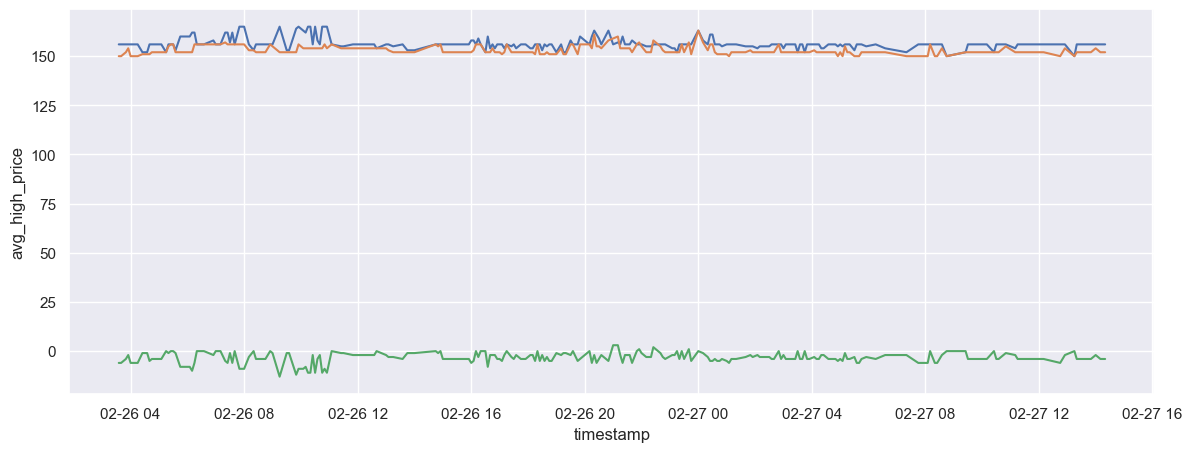

In [ ]:
plt.figure(figsize=(14, 5))

data['timestamp'] = pd.to_datetime( data['timestamp'] , unit='s')

data['spread'] = data['avg_low_price']-data['avg_high_price']

sns.set_theme(style="darkgrid")

sns.lineplot(data, x='timestamp', y='avg_high_price')
sns.lineplot(data, x='timestamp', y='avg_low_price')
plt.figure(figsize=(14, 5))
sns.lineplot(data, x='timestamp', y='spread')


In [21]:

def train_for_item(item_id, db, table='prices_5m',):
    
    logging.info(f"Entrenando modelo para item {item_id}")
    df = OSRSBaseDatos.obtener_precios_id(db, item_id, table)
    
    if len(df) < 25:  # mínimo de datos para entrenar
        logging.warning(f"Item {item_id}: pocos datos ({len(df)}), se omite")
        return

    df_feat = preprocess_item(df)
    if df_feat.empty:
        logging.warning(f"Item {item_id}: no se pudieron generar features")
        return

    X = df_feat.drop('target', axis=1)
    y = df_feat['target']
    # División temporal (80% train, 20% test)
    split = int(len(X) * 0.8)
    X_train, X_test = X.iloc[:split], X.iloc[split:]
    y_train, y_test = y.iloc[:split], y.iloc[split:]

#     model = XGBRegressor(n_estimators=200, learning_rate=0.05, random_state=42, verbosity=0)
#     model.fit(X_train, y_train)

#     y_pred = model.predict(X_test)
#     mae = mean_absolute_error(y_test, y_pred)
#     rmse = np.sqrt(mean_squared_error(y_test, y_pred))
#     logging.info(f"Item {item_id} - MAE: {mae:.2f}, RMSE: {rmse:.2f}")

#     # Guardar modelo
#     joblib.dump(model, f"{MODEL_DIR}/model_{item_id}.pkl")

    # Guardar métricas
    #insert_metric(item_id, int(time.time()), 'XGBoost', mae, rmse)

